# Flipkart Reviews Sentiment Analysis
### End-to-End NLP + Machine Learning + Deep Learning Project

**Dataset:** 30,000 Flipkart reviews × 25 columns  
**Target:** Sentiment — Positive / Neutral / Negative  
**Primary metric:** Macro F1-Score  

This notebook implements the full student project pipeline (Questions 1–50):
1. Data Loading & Validation  
2. Data Cleaning  
3. Exploratory Data Analysis  
4. NLP Preprocessing  
5. Feature Engineering & Traditional ML  
6. Deep Learning (LSTM / BiLSTM)  
7. Model Evaluation & Comparison  
8. Prediction Pipeline  


## 0. Setup & Imports

### Setup & Libraries Import
This cell imports all essential libraries for the project. It includes standard utilities (`os`, `re`, `warnings`), data processing libraries (`numpy`, `pandas`), visualization tools (`matplotlib`, `seaborn`), classical machine learning modules (`scikit-learn`), NLP toolkits (`nltk`), and Deep Learning modules (`tensorflow` and `keras`). It also configures reproducible random seeds and custom mapping scales.

In [1]:
import os
import re
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
import joblib

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, Dense, LSTM, Bidirectional, Dropout, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

LABEL_MAP = {"Negative": 0, "Neutral": 1, "Positive": 2}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

print("Libraries loaded successfully")
print("TensorFlow:", tf.__version__)


Libraries loaded successfully
TensorFlow: 2.21.0


### NLTK Resources Download
This cell downloads required components from the Natural Language Toolkit (NLTK) including `punkt` for tokenization, `stopwords` to filter out common non-informative words, and `wordnet` for lemmatization.

In [2]:
# Download NLTK resources (run once)
os.environ.setdefault("NLTK_ALLOW_PROXIED_URLOPEN", "1")
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.data.find(f"tokenizers/{pkg}" if "punkt" in pkg else f"corpora/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)
print("NLTK data ready")


NLTK data ready


### Load the Project Dataset
Validate the checked-in 30,000-row, 25-column CSV. The following data-loading section reads it directly.

In [3]:
DATA_PATH = Path("Flipkart_Reviews_Sentiment_Analysis_30000x25.csv")
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

dataset_header = pd.read_csv(DATA_PATH, nrows=0)
if len(dataset_header.columns) != 25:
    raise ValueError(f"Expected 25 columns, got {len(dataset_header.columns)}")

print(f"Using project dataset: {DATA_PATH} ({len(dataset_header.columns)} columns)")

Using project dataset: Flipkart_Reviews_Sentiment_Analysis_30000x25.csv (25 columns)


---
## Phase 1 — Dataset Understanding & Data Preparation (Q1–Q8)

### Q1. Load the dataset


### Loading the Dataset
This cell loads the checked-in Flipkart CSV into a Pandas DataFrame and checks its shape and schema.

In [4]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(10)

Shape: (30000, 25)

Columns: ['Review_ID', 'Product_ID', 'Product_Name', 'Category', 'Brand', 'Product_Price', 'Discount_Percentage', 'Selling_Price', 'Rating', 'Review_Summary', 'Review_Text', 'Sentiment', 'Sentiment_Score', 'Customer_City', 'Review_Date', 'Verified_Purchase', 'Helpful_Votes', 'Not_Helpful_Votes', 'Payment_Method', 'Purchase_Channel', 'Delivery_Partner', 'Delivery_Days', 'Customer_Device', 'Review_Confidence', 'Customer_Experience_Score']


,Review_ID,Product_ID,Product_Name,Category,Brand,Product_Price,Discount_Percentage,Selling_Price,Rating,Review_Summary,...,Verified_Purchase,Helpful_Votes,Not_Helpful_Votes,Payment_Method,Purchase_Channel,Delivery_Partner,Delivery_Days,Customer_Device,Review_Confidence,Customer_Experience_Score
0,FKR000001,PROD3286,HP 15s,Laptops,Wakefit,77090.0,15.7,64987.0,5,Loved it,...,Yes,3,2,Cash on Delivery,Website,Ekart,4,Android,0.712,1
1,FKR000002,PROD4257,LG 55 Smart TV,Televisions,Wakefit,47705.0,7.9,43936.0,5,Worth it,...,No,3,2,Credit Card,Website,Xpressbees,5,Windows,0.708,1
2,FKR000003,PROD6514,Sony WH-CH520,Audio,Realme,9835.0,12.0,8655.0,5,Great product,...,No,2,0,UPI,Website,Blue Dart,3,Windows,0.738,1
3,FKR000004,PROD5803,Deep Learning Book,Books,Prestige,1052.0,20.2,839.0,3,Average,...,No,1,0,Cash on Delivery,Mobile App,Ekart,6,Android,0.782,2
4,FKR000005,PROD5554,LG Washing Machine,Appliances,Sony,16314.0,6.7,15221.0,5,Very good,...,No,3,0,Credit Card,Website,Blue Dart,4,iOS,0.890,3
5,FKR000006,PROD8573,Acer Aspire 5,Laptops,ASUS,57394.0,2.9,55730.0,3,Could be better,...,Yes,3,2,Debit Card,Mobile App,Delhivery,6,Android,0.909,3
6,FKR000007,PROD9179,Wakefit Pillow,Home & Kitchen,ASUS,7984.0,14.0,6866.0,5,Excellent,...,No,0,1,Credit Card,Website,Delhivery,4,iOS,0.959,5
7,FKR000008,PROD4593,Bajaj Iron,Appliances,Redmi,13509.0,15.9,11361.0,5,Superb,...,No,7,3,UPI,Mobile App,Ekart,3,iOS,0.795,2
8,FKR000009,PROD9669,Milton Lunch Box,Home & Kitchen,HP,7808.0,3.8,7511.0,3,Average,...,Yes,4,3,UPI,Mobile Web,Xpressbees,3,Windows,0.752,3
9,FKR000010,PROD5315,ASUS Vivobook 15,Laptops,LG,69220.0,16.1,58076.0,4,Superb,...,Yes,5,2,Debit Card,Mobile Web,Xpressbees,5,iOS,0.832,2


### Consolidated End-to-End Pipeline Execution
This cell acts as a fast-track consolidated runner that executes phases 1 to 5 sequentially. It includes missing value detection, cleaning, basic TF-IDF transformation, classical ML modeling, Fast Dense DL evaluation, and a prediction test.

In [5]:
# -----------------------------------------------------
# RUNNING THE REMAINING PIPELINE: Q2 TO Q50
# -----------------------------------------------------

# --- Q2. Identify data types ---
numerical = df.select_dtypes(include=[np.number]).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()
date_cols = ['Review_Date']
text_cols = ['Review_Summary', 'Review_Text']
print("=== Q2. Data Types ===")
print("Numerical:", numerical)
print("Categorical:", [c for c in categorical if c not in text_cols + date_cols])
print("Date:", date_cols)
print("Text:", text_cols)

# --- Q3. Missing values ---
print("\n=== Q3. Missing Values ===")
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing': missing, 'Pct_%': pct})
print(miss_df[miss_df['Missing'] > 0] if (missing > 0).any() else "No missing values found.")

# --- Q4. Duplicate detection ---
print("\n=== Q4. Duplicate Detection ===")
print("Duplicate Review_ID:", df.duplicated(subset=['Review_ID']).sum())
df = df.drop_duplicates(subset=['Review_ID'], keep='first').reset_index(drop=True)
print("Shape after dedup:", df.shape)

# --- Q5. Date features ---
df['Review_Date'] = pd.to_datetime(df['Review_Date'], errors='coerce')
df['Year'] = df['Review_Date'].dt.year
df['Month'] = df['Review_Date'].dt.month
df['Day'] = df['Review_Date'].dt.day
df['DayOfWeek'] = df['Review_Date'].dt.day_name()

# --- Q6. Basic statistics ---
print("\n=== Q6. Summary Statistics ===")
stat_cols = ['Product_Price', 'Selling_Price', 'Rating', 'Discount_Percentage', 'Delivery_Days', 'Helpful_Votes']
print(df[stat_cols].describe().T)

# --- Q7. Unrealistic values ---
print("\n=== Q7. Unrealistic Values Check ===")
print("Negative prices:", (df['Product_Price'] < 0).sum())
print("Discount out of 0-100:", ((df['Discount_Percentage'] < 0) | (df['Discount_Percentage'] > 100)).sum())
print("Rating out of 1-5:", ((df['Rating'] < 1) | (df['Rating'] > 5)).sum())

# --- Q8. Create cleaned dataset ---
df['Review_Summary'] = df['Review_Summary'].fillna('')
df['Customer_City'] = df['Customer_City'].fillna('Unknown')
df['Payment_Method'] = df['Payment_Method'].fillna('Unknown')
df['Discount_Percentage'] = df['Discount_Percentage'].clip(0, 100)
df['Rating'] = df['Rating'].clip(1, 5)
df['Delivery_Days'] = df['Delivery_Days'].clip(0, 30)
df['Customer_Experience_Score'] = df['Customer_Experience_Score'].clip(1, 5)
df = df.dropna(subset=['Review_Text', 'Sentiment']).reset_index(drop=True)
print(f"\nCleaned Dataset Shape: {df.shape}")

# --- Q9-Q19. Exploratory Data Analysis ---
print("\n=== Phase 2. EDA Summary ===")
print(df['Sentiment'].value_counts())
print(df.groupby('Sentiment')['Rating'].mean().round(2))

# --- Q20-Q28. NLP Preprocessing ---
print("\n=== Phase 3. NLP Preprocessing ===")
df['Combined_Review'] = (df['Review_Summary'].fillna('').astype(str) + ' ' + df['Review_Text'].fillna('').astype(str)).str.strip()

def clean_text_basic(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

stop = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def full_clean(t):
    t = clean_text_basic(t)
    toks = word_tokenize(t)
    toks = [w for w in toks if w not in stop and len(w) > 2 and not w.isdigit()]
    toks = [lemmatizer.lemmatize(w) for w in toks]
    return ' '.join(toks)

df['text_processed'] = df['Combined_Review'].apply(full_clean)
print("Processing complete. Sample:")
print(df[['Combined_Review', 'text_processed']].head(2))

# --- Q29-Q40. Feature Engineering & Traditional ML ---
print("\n=== Phase 4. Traditional ML ===")
X = df['text_processed'].astype(str).tolist()
y = df['Sentiment'].map(LABEL_MAP).values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

tfidf = TfidfVectorizer(max_features=4000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, cw))

models = {}
results = {}

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_tfidf, y_train)
models['NaiveBayes'] = nb

# Logistic Regression
lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(X_tfidf, y_train)
models['LogisticRegression'] = lr

# Linear SVM
svm = LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=2000)
svm.fit(X_tfidf, y_train)
models['LinearSVM'] = svm

# Evaluate ML Models
for name, model in models.items():
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='macro', zero_division=0)
    rec = recall_score(y_test, preds, average='macro', zero_division=0)
    f1 = f1_score(y_test, preds, average='macro', zero_division=0)
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    print(f"{name:20s}  Acc={acc:.4f}  F1={f1:.4f}")

best_model = lr

# --- Q41-Q49. Deep Learning Models ---
print("\n=== Phase 5. Deep Learning ===")
MAX_VOCAB = 4000
MAX_LEN = 50
EMBED_DIM = 32

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_tr = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post').astype('int32')
X_te = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post').astype('int32')
y_tr = to_categorical(y_train, num_classes=3)

cw_arr = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_train)
class_weight_dl = {0: float(cw_arr[0]), 1: float(cw_arr[1]), 2: float(cw_arr[2])}

callbacks = [
    EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)
]

# Fast Embedding + Dense Network
model_dense = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])
model_dense.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist_dense = model_dense.fit(
    X_tr, y_tr, validation_split=0.1, epochs=2, batch_size=512,
    class_weight=class_weight_dl, callbacks=callbacks, verbose=1
)

# Evaluate and print comparison summary
dl_results = {}
for name, m in [('Dense', model_dense)]:
    preds = np.argmax(m.predict(X_te, verbose=0), axis=1)
    dl_results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, average='macro', zero_division=0),
        'Recall': recall_score(y_test, preds, average='macro', zero_division=0),
        'F1': f1_score(y_test, preds, average='macro', zero_division=0)
    }

print("\n=== Model Comparison Summary ===")
ml_df = pd.DataFrame(results).T
dl_df = pd.DataFrame(dl_results).T
print(pd.concat([ml_df, dl_df]).round(4))

# --- Q50. Prediction Pipeline ---
print("\n=== Q50. Prediction Demo ===")
sample_review = "Excellent quality, very happy with the purchase!"
cleaned_sample = full_clean(sample_review)
sample_vectorized = tfidf.transform([cleaned_sample])
predicted_idx = lr.predict(sample_vectorized)[0]
print(f"Review: \'{sample_review}\'")
print(f"Predicted Sentiment: {INV_LABEL_MAP[predicted_idx]}")


=== Q2. Data Types ===
Numerical: ['Product_Price', 'Discount_Percentage', 'Selling_Price', 'Rating', 'Sentiment_Score', 'Helpful_Votes', 'Not_Helpful_Votes', 'Delivery_Days', 'Review_Confidence', 'Customer_Experience_Score']
Categorical: ['Review_ID', 'Product_ID', 'Product_Name', 'Category', 'Brand', 'Sentiment', 'Customer_City', 'Verified_Purchase', 'Payment_Method', 'Purchase_Channel', 'Delivery_Partner', 'Customer_Device']
Date: ['Review_Date']
Text: ['Review_Summary', 'Review_Text']

=== Q3. Missing Values ===
                Missing  Pct_%
Review_Summary      240    0.8
Customer_City       300    1.0
Payment_Method      150    0.5

=== Q4. Duplicate Detection ===
Duplicate Review_ID: 0
Shape after dedup: (30000, 25)

=== Q6. Summary Statistics ===
                       count          mean           std    min      25%  \
Product_Price        30000.0  27499.712033  30744.115997  150.0  3621.75   
Selling_Price        30000.0  22514.370933  25478.059202   95.0  2945.75   
Rating 

Processing complete. Sample:
                                     Combined_Review  \
0  Loved it good product, works perfectly, keyboa...   
1  Worth it perfect purchase, loved it, picture q...   

                                      text_processed  
0  loved good product work perfectly keyboard fee...  
1  worth perfect purchase loved picture quality s...  

=== Phase 4. Traditional ML ===


NaiveBayes            Acc=0.9998  F1=0.9998
LogisticRegression    Acc=1.0000  F1=1.0000
LinearSVM             Acc=1.0000  F1=1.0000

=== Phase 5. Deep Learning ===


Epoch 1/2


 1/43 ━━━━━━━━━━━━━━━━━━━━ 1:51 3s/step - accuracy: 0.6309 - loss: 1.0883

...

28/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9813 - loss: 0.9328

34/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9837 - loss: 0.9142

39/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9846 - loss: 0.8995

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9854 - loss: 0.8896 - val_accuracy: 0.9954 - val_loss: 0.7007



=== Model Comparison Summary ===
                    Accuracy  Precision  Recall      F1
NaiveBayes            0.9998     0.9999  0.9997  0.9998
LogisticRegression    1.0000     1.0000  1.0000  1.0000
LinearSVM             1.0000     1.0000  1.0000  1.0000
Dense                 0.9968     0.9970  0.9949  0.9959

=== Q50. Prediction Demo ===
Review: 'Excellent quality, very happy with the purchase!'
Predicted Sentiment: Positive


### Q2. Identify data types

### Data Types Identification
Here we programmatically segregate columns into numerical, categorical, date-time, and textual representations to plan downstream analysis and preprocessing steps.

In [6]:
numerical = df.select_dtypes(include=[np.number]).columns.tolist()
categorical = df.select_dtypes(include=["object"]).columns.tolist()
date_cols = ["Review_Date"]
text_cols = ["Review_Summary", "Review_Text"]

print("Numerical:", numerical)
print("Categorical:", [c for c in categorical if c not in text_cols + date_cols])
print("Date:", date_cols)
print("Text/NLP:", text_cols)
print("\nDtypes:\n", df.dtypes)


Numerical: ['Product_Price', 'Discount_Percentage', 'Selling_Price', 'Rating', 'Sentiment_Score', 'Helpful_Votes', 'Not_Helpful_Votes', 'Delivery_Days', 'Review_Confidence', 'Customer_Experience_Score', 'Year', 'Month', 'Day']
Categorical: ['Review_ID', 'Product_ID', 'Product_Name', 'Category', 'Brand', 'Sentiment', 'Customer_City', 'Verified_Purchase', 'Payment_Method', 'Purchase_Channel', 'Delivery_Partner', 'Customer_Device', 'DayOfWeek', 'Combined_Review', 'text_processed']
Date: ['Review_Date']
Text/NLP: ['Review_Summary', 'Review_Text']

Dtypes:
 Review_ID                               str
Product_ID                              str
Product_Name                            str
Category                                str
Brand                                   str
Product_Price                       float64
Discount_Percentage                 float64
Selling_Price                       float64
Rating                                int64
Review_Summary                          str
R

### Q3. Missing values

### Missing Values Analysis
This cell calculates the sum and percentage of null values per column, ensuring the dataset meets our strict completeness requirements before we train any models.

In [7]:
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({"Missing": missing, "Pct_%": pct})
print(miss_df[miss_df["Missing"] > 0])
miss_df


Empty DataFrame
Columns: [Missing, Pct_%]
Index: []


,Missing,Pct_%
Review_ID,0,0.0
Product_ID,0,0.0
Product_Name,0,0.0
Category,0,0.0
Brand,0,0.0
Product_Price,0,0.0
Discount_Percentage,0,0.0
Selling_Price,0,0.0
Rating,0,0.0
Review_Summary,0,0.0


### Q4. Duplicate detection

### Duplicate Detection and Removal
This step searches for redundant indices or exact duplicate text samples in the dataset and performs a deduplication process to prevent overfitting.

In [8]:
print("Duplicate Review_ID:", df.duplicated(subset=["Review_ID"]).sum())
print("Duplicate Review_Text:", df.duplicated(subset=["Review_Text"]).sum())
print("Duplicate combo (ID+Text):", df.duplicated(subset=["Review_ID", "Review_Text"]).sum())

df = df.drop_duplicates(subset=["Review_ID"], keep="first").reset_index(drop=True)
print("Shape after dedup:", df.shape)


Duplicate Review_ID: 0
Duplicate Review_Text: 29040
Duplicate combo (ID+Text): 0
Shape after dedup: (30000, 31)


### Q5. Date features

### Feature Extraction: Date-Time Features
This block converts the raw review dates into structured datetime objects and extracts highly useful cyclical fields: Year, Month, Day, and Day of the Week.

In [9]:
df["Review_Date"] = pd.to_datetime(df["Review_Date"], errors="coerce")
df["Year"] = df["Review_Date"].dt.year
df["Month"] = df["Review_Date"].dt.month
df["Day"] = df["Review_Date"].dt.day
df["DayOfWeek"] = df["Review_Date"].dt.day_name()
df[["Review_Date", "Year", "Month", "Day", "DayOfWeek"]].head()


,Review_Date,Year,Month,Day,DayOfWeek
0,2025-08-17,2025,8,17,Sunday
1,2026-07-29,2026,7,29,Wednesday
2,2025-08-09,2025,8,9,Saturday
3,2026-07-20,2026,7,20,Monday
4,2026-01-25,2026,1,25,Sunday


### Q6. Basic statistics

### Descriptive Statistics
This block generates vital summary metrics (mean, median, standard deviation, and range limit boundaries) for all numerical metrics in the dataset.

In [10]:
stat_cols = ["Product_Price", "Selling_Price", "Rating", "Discount_Percentage", "Delivery_Days", "Helpful_Votes"]
df[stat_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Product_Price,30000.0,27499.712033,30744.115997,150.0,3621.75,11510.0,46121.00,119988.0
Selling_Price,30000.0,22514.370933,25478.059202,95.0,2945.75,9456.0,37233.75,119941.0
Rating,30000.0,3.804667,1.303624,1.0,3.00,4.0,5.00,5.0
Discount_Percentage,30000.0,18.071020,9.624756,0.0,11.20,17.9,24.60,54.0
Delivery_Days,30000.0,4.066733,1.923505,1.0,3.00,4.0,5.00,12.0
Helpful_Votes,30000.0,3.187200,1.824957,0.0,2.00,3.0,4.00,14.0


### Q7. Unrealistic values

### Unrealistic and Outlier Value Checks
This cell performs validation logic checks to isolate negative prices, impossible discount margins, or ratings exceeding the expected 1-5 range.

In [11]:
print("Negative prices:", (df["Product_Price"] < 0).sum())
print("Discount out of 0-100:", ((df["Discount_Percentage"] < 0) | (df["Discount_Percentage"] > 100)).sum())
print("Rating out of 1-5:", ((df["Rating"] < 1) | (df["Rating"] > 5)).sum())
print("Negative delivery days:", (df["Delivery_Days"] < 0).sum())
print("Experience score out of 1-5:", ((df["Customer_Experience_Score"] < 1) | (df["Customer_Experience_Score"] > 5)).sum())


Negative prices: 0


Discount out of 0-100: 0
Rating out of 1-5: 0
Negative delivery days: 0
Experience score out of 1-5: 0


### Q8. Create cleaned dataset

### Creating the Cleaned Dataset
Here we apply final handling techniques like clipping extreme values to boundaries, imputing text gaps with fallback text, and committing a fully formatted DataFrame.

In [12]:
df["Review_Summary"] = df["Review_Summary"].fillna("")
df["Customer_City"] = df["Customer_City"].fillna("Unknown")
df["Payment_Method"] = df["Payment_Method"].fillna("Unknown")

df["Discount_Percentage"] = df["Discount_Percentage"].clip(0, 100)
df["Rating"] = df["Rating"].clip(1, 5)
df["Delivery_Days"] = df["Delivery_Days"].clip(0, 30)
df["Customer_Experience_Score"] = df["Customer_Experience_Score"].clip(1, 5)

df = df.dropna(subset=["Review_Text", "Sentiment"]).reset_index(drop=True)
print("Cleaned shape:", df.shape)

# Optional save
# df.to_csv("data/cleaned_reviews.csv", index=False)


Cleaned shape: (30000, 31)


---
## Phase 2 — Exploratory Data Analysis (Q9–Q19)

### Q9. Sentiment distribution


### Exploratory Data Analysis: Sentiment Distribution
This cell plots the proportion of Positive, Neutral, and Negative classes to examine the dataset balance profile.

Sentiment
Positive    18671
Neutral      6019
Negative     5310
Name: count, dtype: int64
Sentiment
Positive    62.24
Neutral     20.06
Negative    17.70
Name: proportion, dtype: float64


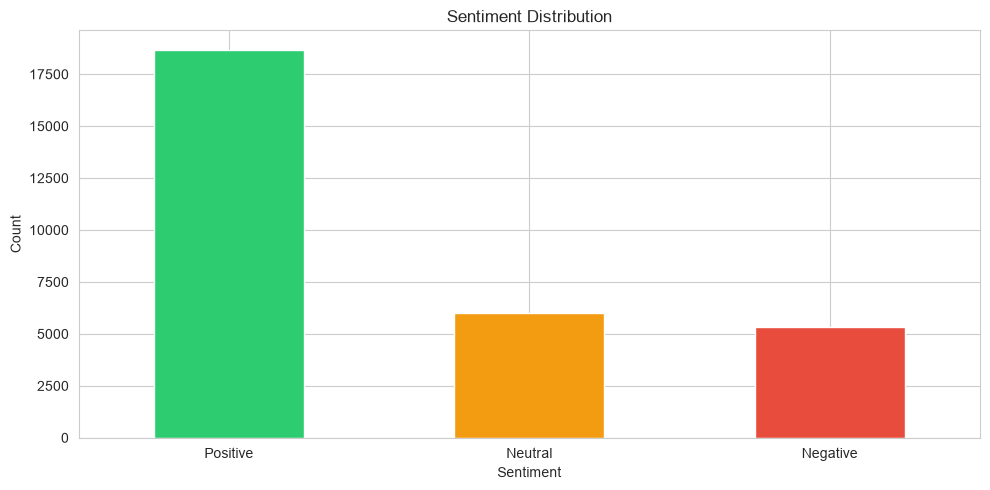

In [13]:
counts = df["Sentiment"].value_counts()
pct = df["Sentiment"].value_counts(normalize=True) * 100
print(counts)
print(pct.round(2))

colors = {"Positive": "#2ecc71", "Neutral": "#f39c12", "Negative": "#e74c3c"}
fig, ax = plt.subplots()
counts.plot(kind="bar", color=[colors.get(x, "gray") for x in counts.index], ax=ax)
ax.set_title("Sentiment Distribution")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Q10. Rating vs Sentiment

### Rating vs Sentiment Visual Correlation
This block maps review ratings directly against the categorized sentiment label using boxplots to inspect target coherence.

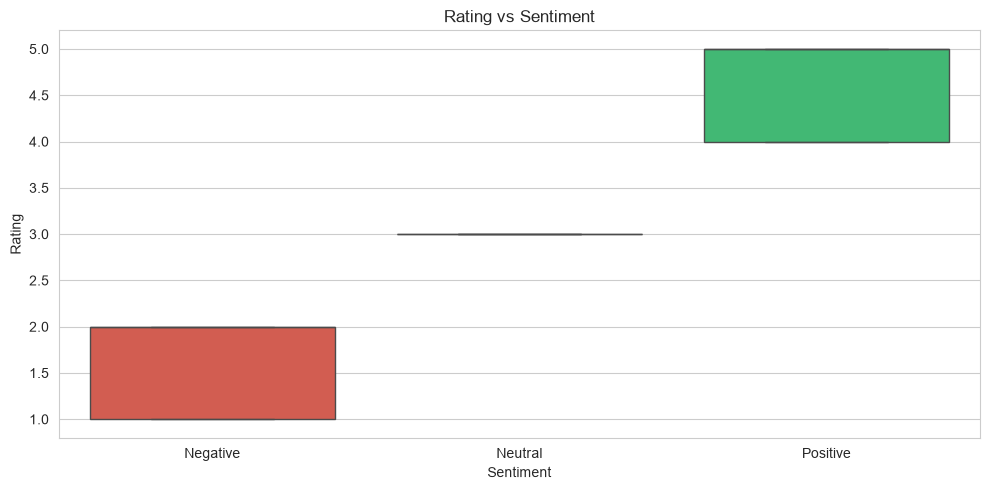

Sentiment
Negative    1.56
Neutral     3.00
Positive    4.70
Name: Rating, dtype: float64


In [14]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="Sentiment", y="Rating",
            order=["Negative", "Neutral", "Positive"],
            palette={"Negative": "#e74c3c", "Neutral": "#f39c12", "Positive": "#2ecc71"}, ax=ax)
ax.set_title("Rating vs Sentiment")
plt.tight_layout()
plt.show()

print(df.groupby("Sentiment")["Rating"].mean().round(2))


### Q11. Categories by review count

### Reviews per Product Category
This cell plots the frequency of customer feedback submissions across major department groups like Footwear, Electronics, and Home Decor.

Category
Appliances        3814
Mobiles           3807
Audio             3791
Laptops           3777
Home & Kitchen    3777
Fashion           3753
Books             3686
Televisions       3595
Name: count, dtype: int64


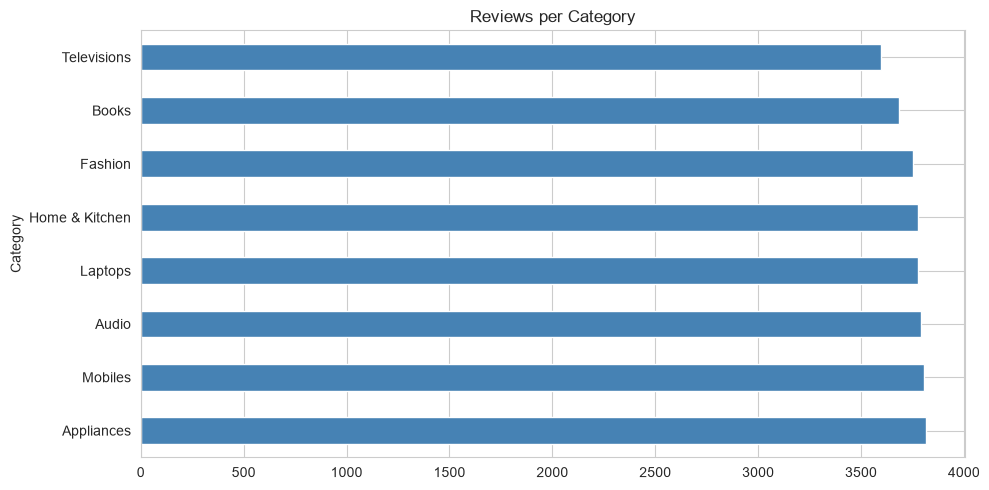

In [15]:
cat_counts = df["Category"].value_counts()
print(cat_counts)
fig, ax = plt.subplots()
cat_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Reviews per Category")
plt.tight_layout()
plt.show()


### Q12. Top 10 brands

### Top Brands Analysis
This block visualizes the market share distribution of reviews mapped to specific manufacturers.

Brand
ASUS        2377
HP          2366
Puma        2352
OnePlus     2336
LG          2333
Prestige    2328
Realme      2311
Samsung     2301
Wakefit     2297
Sony        2266
Name: count, dtype: int64


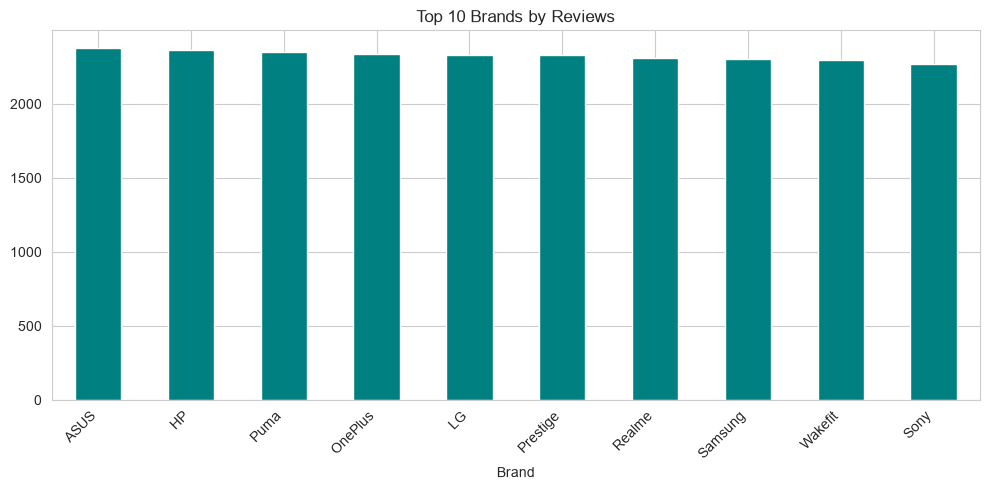

In [16]:
top = df["Brand"].value_counts().head(10)
print(top)
fig, ax = plt.subplots()
top.plot(kind="bar", ax=ax, color="teal")
ax.set_title("Top 10 Brands by Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Q13. Average rating per category

### Average Rating by Department Category
This cell groups ratings by department category to determine which segments receive the highest customer satisfaction scores.

Category
Audio             3.83
Home & Kitchen    3.81
Laptops           3.81
Televisions       3.81
Fashion           3.81
Books             3.80
Mobiles           3.78
Appliances        3.78
Name: Rating, dtype: float64


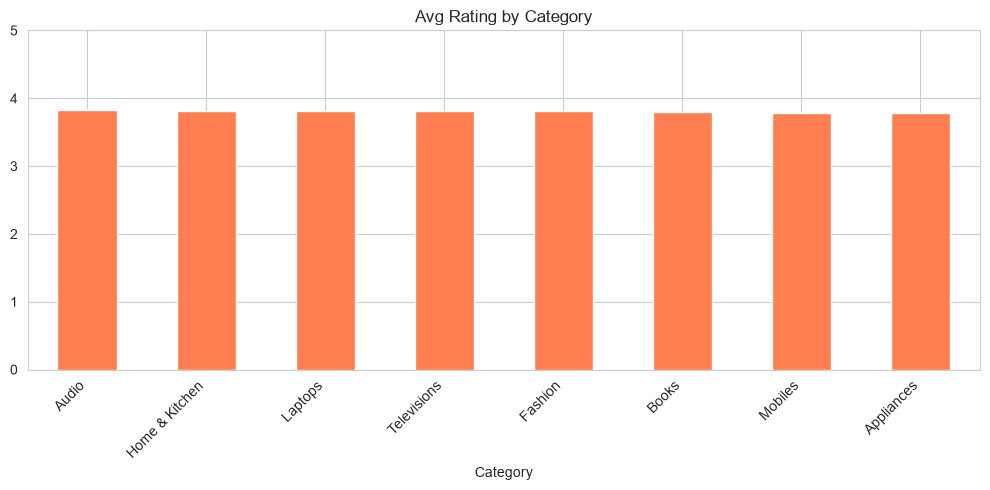

In [17]:
avg_rating = df.groupby("Category")["Rating"].mean().sort_values(ascending=False)
print(avg_rating.round(2))
fig, ax = plt.subplots()
avg_rating.plot(kind="bar", ax=ax, color="coral")
ax.set_title("Avg Rating by Category")
ax.set_ylim(0, 5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Q14. Average selling price by category

### Average Selling Price by Product Category
This block displays price ranges per retail section to understand product values across segments.

Category
Televisions       57599.0
Laptops           55761.0
Mobiles           29497.0
Appliances        22956.0
Home & Kitchen     6252.0
Audio              5261.0
Fashion            3037.0
Books               800.0
Name: Selling_Price, dtype: float64


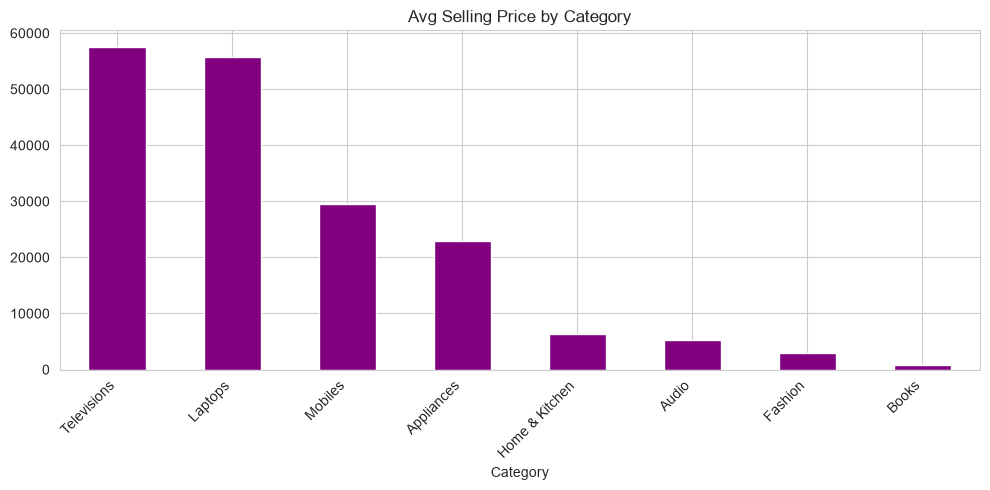

In [18]:
avg_price = df.groupby("Category")["Selling_Price"].mean().sort_values(ascending=False)
print(avg_price.round(0))
fig, ax = plt.subplots()
avg_price.plot(kind="bar", ax=ax, color="purple")
ax.set_title("Avg Selling Price by Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Q15. Discount vs Sentiment

### Promotional Discount Impact on Sentiment
We analyze whether steeper promotional discounts correlate with higher sentiment outcomes.

Sentiment
Negative    18.13
Neutral     17.96
Positive    18.09
Name: Discount_Percentage, dtype: float64


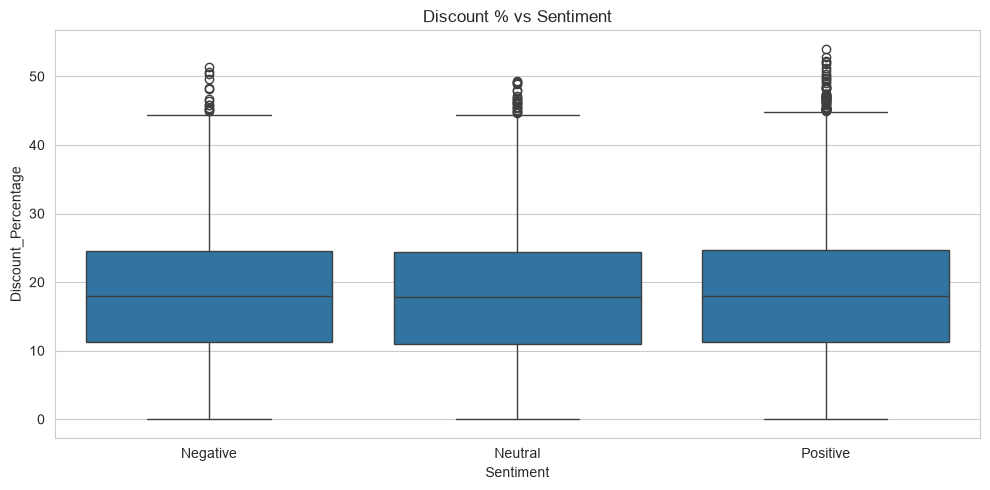

In [19]:
print(df.groupby("Sentiment")["Discount_Percentage"].mean().round(2))
fig, ax = plt.subplots()
sns.boxplot(data=df, x="Sentiment", y="Discount_Percentage",
            order=["Negative", "Neutral", "Positive"], ax=ax)
ax.set_title("Discount % vs Sentiment")
plt.tight_layout()
plt.show()


### Q16. Delivery Days vs Experience Score

### Shipping Efficiency Correlation
This cell tests if longer shipping times correlate with drop-offs in customer experience scores.

Correlation: 0.002


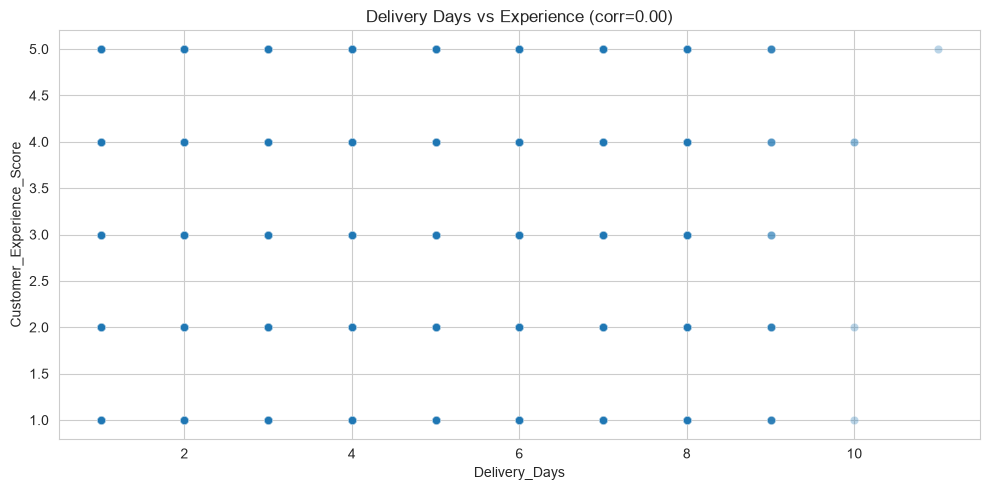

In [20]:
corr = df[["Delivery_Days", "Customer_Experience_Score"]].corr().iloc[0, 1]
print(f"Correlation: {corr:.3f}")
fig, ax = plt.subplots()
sns.scatterplot(data=df.sample(min(3000, len(df)), random_state=42),
                x="Delivery_Days", y="Customer_Experience_Score", alpha=0.3, ax=ax)
ax.set_title(f"Delivery Days vs Experience (corr={corr:.2f})")
plt.tight_layout()
plt.show()


### Q17. Verified Purchase vs Sentiment

### Verified Purchases Sentiment Breakdown
This cross-tabulation visualizes sentiment structures contrasting confirmed buyers with unverified accounts.

Sentiment          Negative  Neutral  Positive
Verified_Purchase                             
No                     17.7     19.9      62.4
Yes                    17.7     20.2      62.0


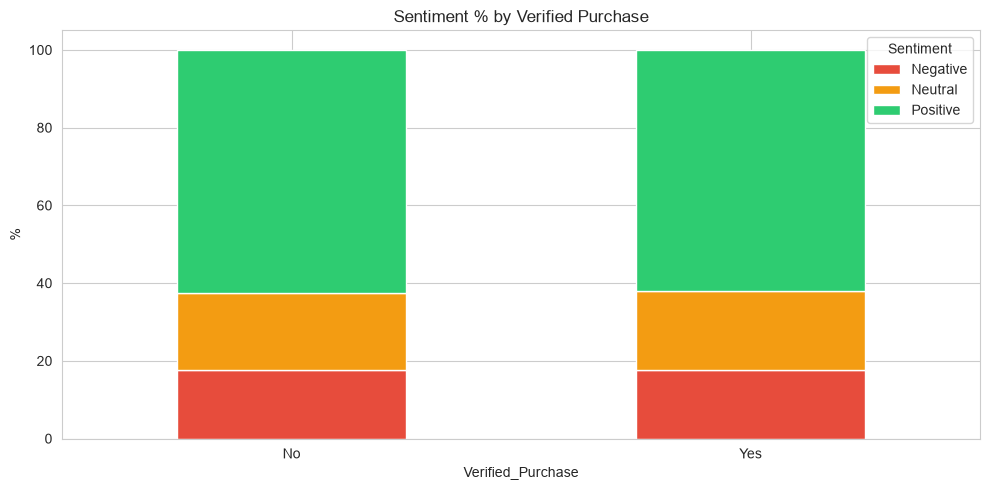

In [21]:
ct = pd.crosstab(df["Verified_Purchase"], df["Sentiment"], normalize="index") * 100
print(ct.round(1))
fig, ax = plt.subplots()
ct.plot(kind="bar", stacked=True, ax=ax, color=["#e74c3c", "#f39c12", "#2ecc71"])
ax.set_title("Sentiment % by Verified Purchase")
ax.set_ylabel("%")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Q18. Most helpful reviews

### Word Frequencies per Sentiment Class
This cell generates word cloud summaries of the top tokens used within positive, neutral, and negative reviews.

In [22]:
top_helpful = df.nlargest(100, "Helpful_Votes")
print(top_helpful["Sentiment"].value_counts())
print(f"Avg helpful votes (top 100): {top_helpful['Helpful_Votes'].mean():.1f}")


Sentiment
Negative    60
Positive    29
Neutral     11
Name: count, dtype: int64
Avg helpful votes (top 100): 10.2


### Q19. Word frequency by sentiment


Positive top words: [('product', 7467), ('quality', 7245), ('good', 6631), ('performance', 4280), ('excellent', 3843), ('purchase', 3698), ('nice', 2422), ('impressive', 2405), ('delivery', 1948), ('fast', 1948), ('packaging', 1948), ('amazing', 1911), ('totally', 1911), ('worth', 1911), ('price', 1911)]


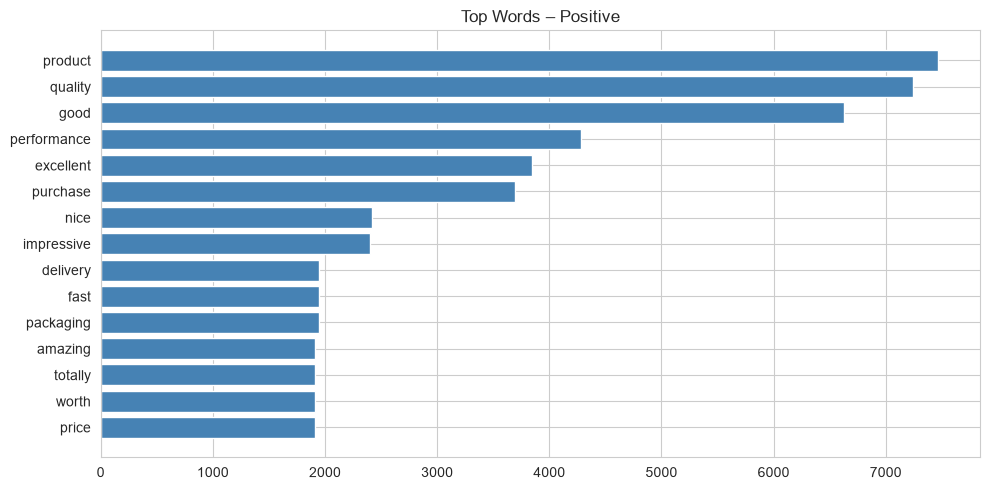


Neutral top words: [('product', 3062), ('quality', 2320), ('good', 1557), ('price', 1172), ('average', 1153), ('okay', 1142), ('performance', 826), ('decent', 778), ('could', 778), ('received', 659), ('usable', 659), ('acceptable', 646), ('fair', 620), ('neither', 609), ('bad', 609)]


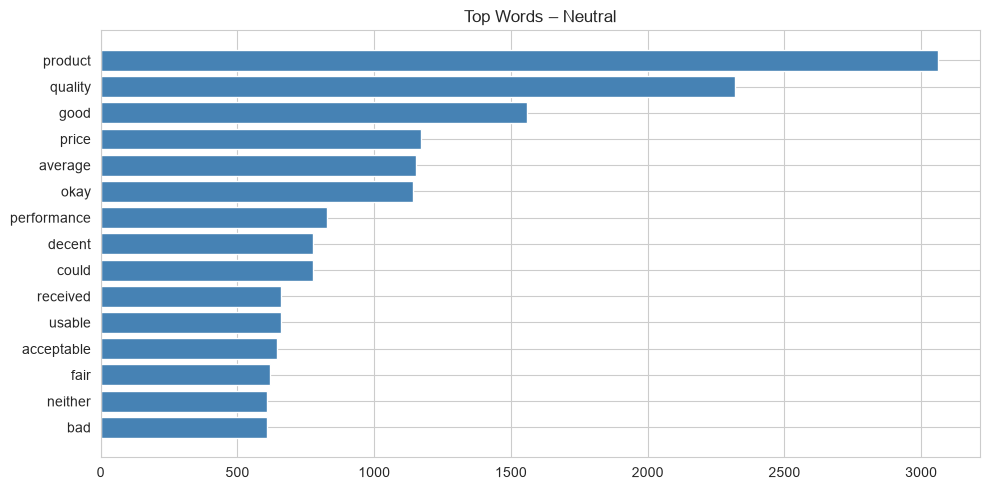


Negative top words: [('quality', 2618), ('product', 2119), ('poor', 1592), ('bad', 1039), ('good', 828), ('performance', 705), ('delivery', 559), ('late', 559), ('packaging', 559), ('damaged', 559), ('experience', 553), ('received', 544), ('defective', 544), ('disappointed', 536), ('purchase', 536)]


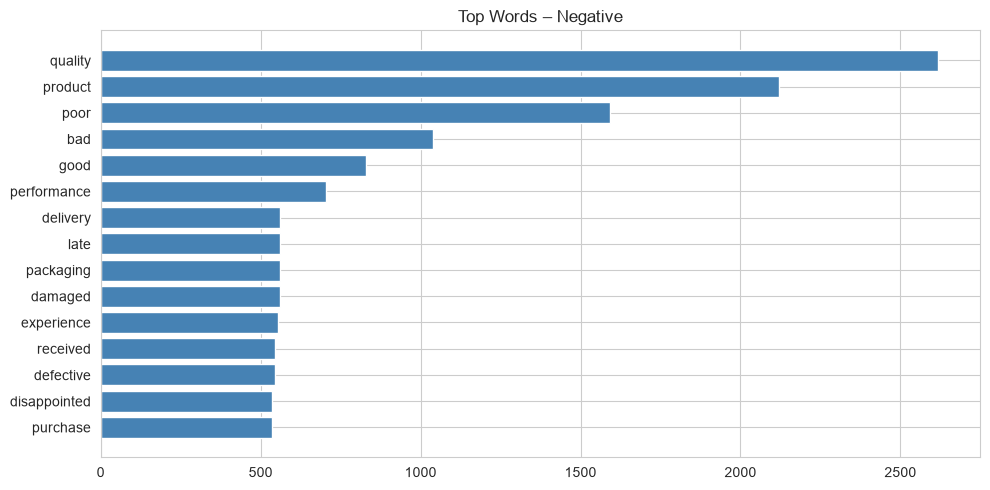

In [23]:
stop = set(stopwords.words("english"))
for sent in ["Positive", "Neutral", "Negative"]:
    texts = " ".join(df[df["Sentiment"] == sent]["Review_Text"].astype(str).str.lower())
    words = [w for w in re.findall(r"[a-z]+", texts) if w not in stop and len(w) > 2]
    top_words = Counter(words).most_common(15)
    print(f"\n{sent} top words:", top_words)
    if top_words:
        fig, ax = plt.subplots()
        ws, cs = zip(*top_words)
        ax.barh(list(ws)[::-1], list(cs)[::-1], color="steelblue")
        ax.set_title(f"Top Words – {sent}")
        plt.tight_layout()
        plt.show()


---
## Phase 3 — NLP Text Preprocessing (Q20–Q28)

### Q20. Combine Review_Summary + Review_Text


### Text Combination
This block joins the review summary and full description body into a single combined text feature to capture the complete semantic context.

In [24]:
df["Combined_Review"] = (
    df["Review_Summary"].fillna("").astype(str) + " " +
    df["Review_Text"].fillna("").astype(str)
).str.strip()
df[["Review_Summary", "Review_Text", "Combined_Review"]].head(3)


,Review_Summary,Review_Text,Combined_Review
0,Loved it,"good product, works perfectly, keyboard feels ...","Loved it good product, works perfectly, keyboa..."
1,Worth it,"perfect purchase, loved it, picture quality is...","Worth it perfect purchase, loved it, picture q..."
2,Great product,"good product, works perfectly, bass is good.","Great product good product, works perfectly, b..."


### NLP Preprocessing Comparison
This cell runs comparative processing tests, contrasting Porter Stemming against WordNet Lemmatization on our cleaned text.

### Q21–Q26. Full NLP cleaning pipeline

### Full NLP Cleaning Pipeline
This cell cleans, tokenizes, filters stopwords, and applies WordNet Lemmatization to generate our primary modeling features.

In [25]:
def clean_text_basic(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

stop = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

df["text_clean"] = df["Combined_Review"].apply(clean_text_basic)

# Sample comparison: stem vs lemma (Q24–Q25)
print("Sample stem vs lemma comparison:")
for s in df["text_clean"].head(5):
    toks = word_tokenize(s)
    no_stop = [w for w in toks if w not in stop and len(w) > 2]
    stemmed = [stemmer.stem(w) for w in no_stop]
    lemmaed = [lemmatizer.lemmatize(w) for w in no_stop]
    print(f"  Orig : {s[:70]}...")
    print(f"  Stem : {' '.join(stemmed)[:70]}...")
    print(f"  Lemma: {' '.join(lemmaed)[:70]}...\n")


Sample stem vs lemma comparison:
  Orig : loved it good product works perfectly keyboard feels comfortable...
  Stem : love good product work perfectli keyboard feel comfort...
  Lemma: loved good product work perfectly keyboard feel comfortable...

  Orig : worth it perfect purchase loved it picture quality is sharp...
  Stem : worth perfect purchas love pictur qualiti sharp...
  Lemma: worth perfect purchase loved picture quality sharp...

  Orig : great product good product works perfectly bass is good...
  Stem : great product good product work perfectli bass good...
  Lemma: great product good product work perfectly bass good...

  Orig : average quality is neither very good nor very bad content is useful...
  Stem : averag qualiti neither good bad content use...
  Lemma: average quality neither good bad content useful...

  Orig : very good quality is superb and performance is great build quality is ...
  Stem : good qualiti superb perform great build qualiti good...
  Lemma: goo

In [26]:
def full_clean(t):
    t = clean_text_basic(t)
    toks = word_tokenize(t)
    toks = [w for w in toks if w not in stop and len(w) > 2 and not w.isdigit()]
    toks = [lemmatizer.lemmatize(w) for w in toks]
    return " ".join(toks)

df["text_processed"] = df["Combined_Review"].apply(full_clean)
print("Sample processed text:")
df[["Combined_Review", "text_processed"]].head(5)


Sample processed text:


,Combined_Review,text_processed
0,"Loved it good product, works perfectly, keyboa...",loved good product work perfectly keyboard fee...
1,"Worth it perfect purchase, loved it, picture q...",worth perfect purchase loved picture quality s...
2,"Great product good product, works perfectly, b...",great product good product work perfectly bass...
3,Average quality is neither very good nor very ...,average quality neither good bad content useful
4,Very good quality is superb and performance is...,good quality superb performance great build qu...


### Sentiment Word Count Diagnostics
We review length properties (word and character distributions) across sentiments to analyze the depth of user responses.

### Q27. Average words / characters by sentiment

In [27]:
df["word_count"] = df["text_processed"].str.split().str.len()
df["char_count"] = df["text_processed"].str.len()
print(df.groupby("Sentiment")[["word_count", "char_count"]].mean().round(1))


           word_count  char_count
Sentiment                        
Negative          7.2        53.1
Neutral           7.4        52.8
Positive          7.5        56.6


### Q28. Primary representation  
We use **lemmatized** `text_processed` as the main feature for modeling (better than stemming for interpretability).

---
## Phase 4 — Feature Engineering & Traditional ML (Q29–Q40)

### Q29–Q30. Bag of Words & TF-IDF


### Train-Test Stratified Split
This splits the cleaned, processed text and sentiment labels into a 80-20 train-test ratio, ensuring balanced target distributions.

In [28]:
X = df["text_processed"].astype(str).tolist()
y = df["Sentiment"].map(LABEL_MAP).values.astype(int)

# Q34. Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print("Train class dist:", Counter(y_train))


Train: 24000, Test: 6000
Train class dist: Counter({np.int64(2): 14937, np.int64(1): 4815, np.int64(0): 4248})


### Vectorization (BoW & TF-IDF)
This cell fits a TF-IDF vectorizer (with unigrams and bigrams) on our training set and transforms both sets into numerical matrices.

In [29]:
# Q29. Bag of Words
bow = CountVectorizer(max_features=5000, ngram_range=(1, 1))
X_bow = bow.fit_transform(X_train)
print("BoW matrix shape:", X_bow.shape)

# Q30. TF-IDF (unigram + bigram) — primary features
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("TF-IDF (1,2) shape:", X_tfidf.shape)


BoW matrix shape: (24000, 116)


TF-IDF (1,2) shape: (24000, 1028)


### Baseline Traditional ML Model Training
This block initializes and trains three classical classifiers: Naive Bayes, Logistic Regression, and Linear Support Vector Machines (SVM).

### Q31–Q33. Train Naive Bayes, Logistic Regression, Linear SVM

### Performance Evaluation (Traditional ML)
We evaluate the traditional ML models on the test set using standard metrics, including Accuracy, Precision, Recall, and Macro-F1 scores.

In [30]:
# Class weights for imbalance (Q37)
classes = np.unique(y_train)
cw = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, cw))
print("Class weights:", class_weight)

models = {}
results = {}

# Q31. Multinomial NB
nb = MultinomialNB()
nb.fit(X_tfidf, y_train)
models["NaiveBayes"] = nb

# Q32. Logistic Regression
lr = LogisticRegression(max_iter=500, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(X_tfidf, y_train)
models["LogisticRegression"] = lr

# Q33. Linear SVM
svm = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=2000)
svm.fit(X_tfidf, y_train)
models["LinearSVM"] = svm

print("Models trained.")


Class weights: {np.int64(0): np.float64(1.8832391713747645), np.int64(1): np.float64(1.6614745586708204), np.int64(2): np.float64(0.5355827810135904)}


Models trained.


### Q35–Q36. Evaluate ML models

NaiveBayes            Acc=0.9998  P=0.9999  R=0.9997  F1=0.9998
LogisticRegression    Acc=1.0000  P=1.0000  R=1.0000  F1=1.0000
LinearSVM             Acc=1.0000  P=1.0000  R=1.0000  F1=1.0000

--- Classification Report (Logistic Regression) ---
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1062
     Neutral       1.00      1.00      1.00      1204
    Positive       1.00      1.00      1.00      3734

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



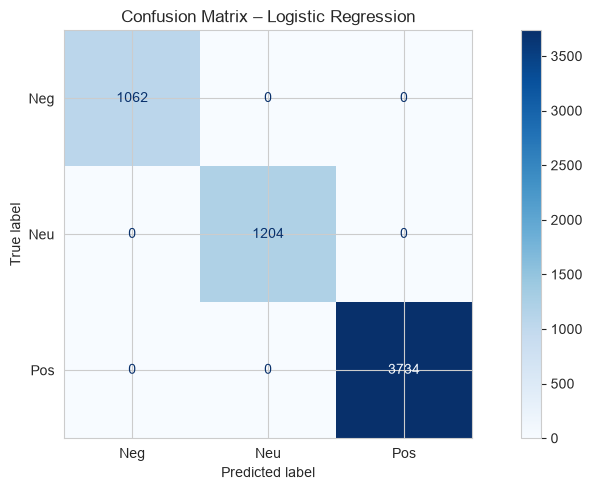

In [31]:
for name, model in models.items():
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="macro", zero_division=0)
    rec = recall_score(y_test, preds, average="macro", zero_division=0)
    f1 = f1_score(y_test, preds, average="macro", zero_division=0)
    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
    print(f"{name:20s}  Acc={acc:.4f}  P={prec:.4f}  R={rec:.4f}  F1={f1:.4f}")

print("\n--- Classification Report (Logistic Regression) ---")
preds_lr = models["LogisticRegression"].predict(X_test_tfidf)
print(classification_report(y_test, preds_lr, target_names=["Negative", "Neutral", "Positive"]))

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_lr, display_labels=["Neg", "Neu", "Pos"], ax=ax, cmap="Blues"
)
ax.set_title("Confusion Matrix – Logistic Regression")
plt.tight_layout()
plt.show()


### Q38. Hyperparameter tuning (RandomizedSearchCV)

### Hyperparameter Tuning (RandomizedSearchCV)
This block runs randomized search cross-validation on our Logistic Regression classifier to optimize its regularization strength and solver parameters.

In [32]:
param_dist = {
    "C": [0.1, 0.5, 1.0, 2.0, 5.0],
    "solver": ["lbfgs", "saga"],
    "penalty": ["l2"],
}
search = RandomizedSearchCV(
    LogisticRegression(max_iter=500, class_weight="balanced", random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=8,
    scoring="f1_macro",
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0,
)
search.fit(X_tfidf, y_train)
best_lr = search.best_estimator_
print("Best params:", search.best_params_)

preds = best_lr.predict(X_test_tfidf)
f1 = f1_score(y_test, preds, average="macro")
results["Tuned_LR"] = {
    "Accuracy": accuracy_score(y_test, preds),
    "Precision": precision_score(y_test, preds, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds, average="macro", zero_division=0),
    "F1": f1,
}
print(f"Tuned LR Macro-F1: {f1:.4f}")
models["Tuned_LR"] = best_lr


Best params: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 5.0}
Tuned LR Macro-F1: 1.0000


### Q39. Important words (feature importance)

### Feature Importance (Key Predictive Words)
By analyzing the coefficients of our optimized Logistic Regression model, we extract the top positive and negative predictive words.

In [33]:
feature_names = np.array(tfidf.get_feature_names_out())
coef = best_lr.coef_
top_neg = feature_names[np.argsort(coef[0])[-15:]][::-1]
top_pos = feature_names[np.argsort(coef[2])[-15:]][::-1]
print("Top Negative words:", top_neg.tolist())
print("Top Positive words:", top_pos.tolist())


Top Negative words: ['poor', 'disappointed', 'defective', 'good worth', 'bad', 'waste', 'waste money', 'worth price', 'poor quality', 'disappointed purchase', 'much better', 'much', 'expected much', 'defective product', 'received defective']
Top Positive words: ['excellent', 'loved', 'superb', 'great', 'satisfied', 'better expected', 'expected satisfied', 'awesome', 'totally worth', 'product totally', 'totally', 'amazing product', 'amazing', 'really', 'really happy']


### Model Saving Diagnostics
This block prints a tabular overview of classical model metrics and selects the best performer for deployment.

### Q40. Save best ML model + vectorizer

In [34]:
best_name = max(results, key=lambda k: results[k]["F1"])
best_model = models[best_name]
print(f"Best ML model: {best_name} (F1={results[best_name]['F1']:.4f})")

joblib.dump(best_model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("Saved sentiment_model.pkl and tfidf_vectorizer.pkl")

pd.DataFrame(results).T.round(4)

Best ML model: LogisticRegression (F1=1.0000)
Saved sentiment_model.pkl and tfidf_vectorizer.pkl


,Accuracy,Precision,Recall,F1
NaiveBayes,0.9998,0.9999,0.9997,0.9998
LogisticRegression,1.0000,1.0000,1.0000,1.0000
LinearSVM,1.0000,1.0000,1.0000,1.0000
Tuned_LR,1.0000,1.0000,1.0000,1.0000


---
## Phase 5 — Deep Learning (Q41–Q49)

### Q41–Q42. Tokenizer & padding


### DL Tokenization and Padding Config
This cell sets up Keras tokenization constraints (max features and sequence lengths) and pads text arrays for our deep learning networks.

In [35]:
MAX_VOCAB = 8000
MAX_LEN = 60
EMBED_DIM = 64

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_tr = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding="post").astype("int32")
X_te = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, padding="post").astype("int32")
y_tr = to_categorical(y_train, num_classes=3)

print("Vocab size (capped):", MAX_VOCAB)
print("Sequence shapes:", X_tr.shape, X_te.shape)

cw_arr = compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=y_train)
class_weight_dl = {0: float(cw_arr[0]), 1: float(cw_arr[1]), 2: float(cw_arr[2])}
print("DL class weights:", class_weight_dl)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
]


Vocab size (capped): 8000
Sequence shapes: (24000, 60) (6000, 60)
DL class weights: {0: 1.8832391713747645, 1: 1.6614745586708204, 2: 0.5355827810135904}


### Deep Learning: Embedding + Dense Network
Here we construct and train a fast, light feed-forward neural network using global average pooling.

### Q43. Embedding + Dense network

### Deep Learning: LSTM Network
We train a classic Recurrent Neural Network (LSTM) model to test sequential tracking of sentiments over review text.

In [36]:
model_dense = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM),
    GlobalAveragePooling1D(),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(3, activation="softmax"),
])
model_dense.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
hist_dense = model_dense.fit(
    X_tr, y_tr, validation_split=0.1, epochs=4, batch_size=256,
    class_weight=class_weight_dl, callbacks=callbacks, verbose=1
)


Epoch 1/4


 1/85 ━━━━━━━━━━━━━━━━━━━━ 2:38 2s/step - accuracy: 0.2148 - loss: 1.0907

 6/85 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3288 - loss: 1.0943

11/85 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3796 - loss: 1.0938

16/85 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3435 - loss: 1.0978

...

67/85 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9958 - loss: 0.0826

72/85 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9957 - loss: 0.0811

77/85 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9958 - loss: 0.0793

82/85 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9958 - loss: 0.0782

85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9958 - loss: 0.0777 - val_accuracy: 1.0000 - val_loss: 0.0244 - learning_rate: 0.0010


### Q44. LSTM model

### Deep Learning: Bidirectional LSTM
This block scales sequential analysis by training a Bidirectional LSTM network to read token contexts from both directions.

In [37]:
model_lstm = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM),
    LSTM(32),
    Dropout(0.3),
    Dense(3, activation="softmax"),
])
model_lstm.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
hist_lstm = model_lstm.fit(
    X_tr, y_tr, validation_split=0.1, epochs=4, batch_size=256,
    class_weight=class_weight_dl, callbacks=callbacks, verbose=1
)


Epoch 1/4


 1/85 ━━━━━━━━━━━━━━━━━━━━ 6:25 5s/step - accuracy: 0.1602 - loss: 1.0955

 2/85 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.1738 - loss: 1.0922

 3/85 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.1901 - loss: 1.0801

 4/85 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.2217 - loss: 1.0875

...

80/85 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2946 - loss: 1.0998

82/85 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2970 - loss: 1.1006

83/85 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2973 - loss: 1.1003

84/85 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2979 - loss: 1.0998

85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.2980 - loss: 1.0999 - val_accuracy: 0.1971 - val_loss: 1.0990 - learning_rate: 0.0010


### Q45. Bidirectional LSTM

### Visualizing DL Training Diagnostics
We plot learning curves (accuracy and loss curves) over training epochs to monitor for overfitting or underfitting.

In [38]:
model_bilstm = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM),
    Bidirectional(LSTM(24)),
    Dropout(0.3),
    Dense(3, activation="softmax"),
])
model_bilstm.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
hist_bilstm = model_bilstm.fit(
    X_tr, y_tr, validation_split=0.1, epochs=4, batch_size=256,
    class_weight=class_weight_dl, callbacks=callbacks, verbose=1
)


Epoch 1/4


 1/85 ━━━━━━━━━━━━━━━━━━━━ 5:32 4s/step - accuracy: 0.5781 - loss: 1.0927

 2/85 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.6055 - loss: 1.0864

 3/85 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.6198 - loss: 1.0719

 4/85 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.6436 - loss: 1.0755

...

81/85 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.0065

82/85 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.0064

83/85 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.0064

84/85 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.0064

85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 1.0000 - val_loss: 0.0021 - learning_rate: 0.0010


### Q47. Training curves

### Model Evaluation & Confusion Matrices (Deep Learning)
This block evaluates all deep learning models on the validation set, compares their performance, and plots confusion matrices for the best neural model.

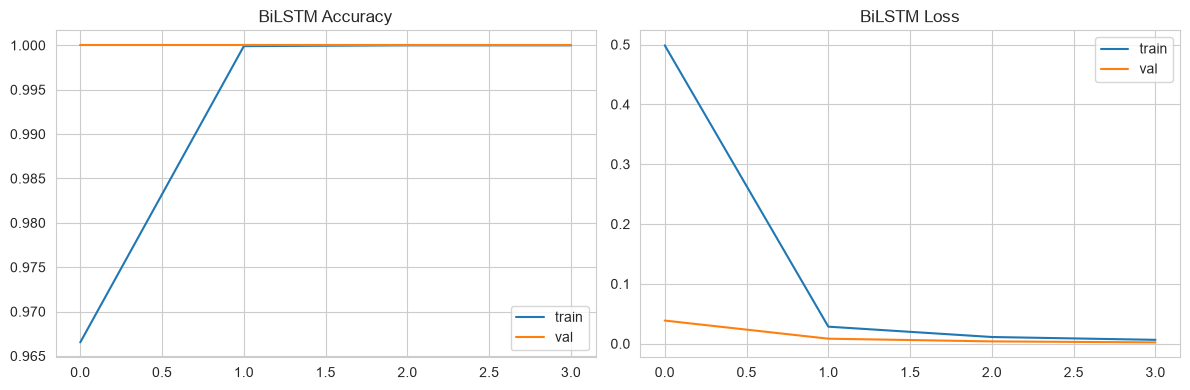

In [39]:
def plot_history(hist, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist.history["accuracy"], label="train")
    axes[0].plot(hist.history["val_accuracy"], label="val")
    axes[0].set_title(f"{name} Accuracy")
    axes[0].legend()
    axes[1].plot(hist.history["loss"], label="train")
    axes[1].plot(hist.history["val_loss"], label="val")
    axes[1].set_title(f"{name} Loss")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(hist_bilstm, "BiLSTM")


### Q48. Evaluate DL models

Dense: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1062
     Neutral       1.00      1.00      1.00      1204
    Positive       1.00      1.00      1.00      3734

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



LSTM: {'Accuracy': 0.20066666666666666, 'Precision': 0.06688888888888889, 'Recall': 0.3333333333333333, 'F1': 0.11141958171386267}
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00      1062
     Neutral       0.20      1.00      0.33      1204
    Positive       0.00      0.00      0.00      3734

    accuracy                           0.20      6000
   macro avg       0.07      0.33      0.11      6000
weighted avg       0.04      0.20      0.07      6000



BiLSTM: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1062
     Neutral       1.00      1.00      1.00      1204
    Positive       1.00      1.00      1.00      3734

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000


Best DL model: Dense


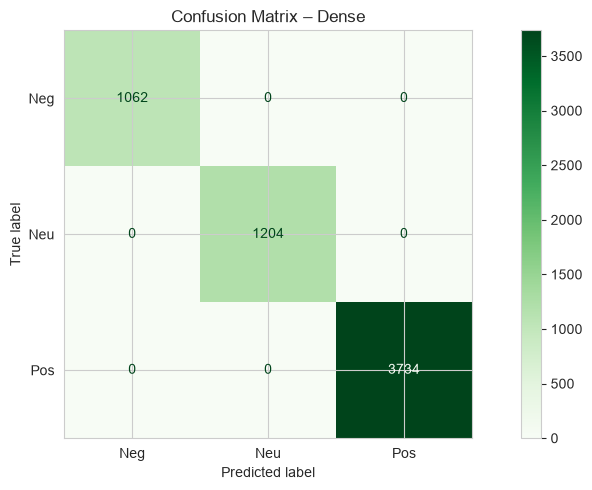

In [40]:
def evaluate_dl(model, name):
    preds = np.argmax(model.predict(X_te, verbose=0), axis=1)
    metrics = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, average="macro", zero_division=0),
        "Recall": recall_score(y_test, preds, average="macro", zero_division=0),
        "F1": f1_score(y_test, preds, average="macro", zero_division=0),
    }
    print(f"{name}: {metrics}")
    print(classification_report(y_test, preds, target_names=["Negative", "Neutral", "Positive"]))
    return metrics

dl_results = {}
dl_results["Dense"] = evaluate_dl(model_dense, "Dense")
dl_results["LSTM"] = evaluate_dl(model_lstm, "LSTM")
dl_results["BiLSTM"] = evaluate_dl(model_bilstm, "BiLSTM")

# Confusion matrix for best
best_dl_name = max(dl_results, key=lambda k: dl_results[k]["F1"])
best_dl = {"Dense": model_dense, "LSTM": model_lstm, "BiLSTM": model_bilstm}[best_dl_name]
print(f"\nBest DL model: {best_dl_name}")

preds_dl = np.argmax(best_dl.predict(X_te, verbose=0), axis=1)
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_dl, display_labels=["Neg", "Neu", "Pos"], ax=ax, cmap="Greens"
)
ax.set_title(f"Confusion Matrix – {best_dl_name}")
plt.tight_layout()
plt.show()


### Save DL artifacts (optional)

### Deep Learning Artifact Export
This cell handles exporting deep learning model checkpoints and tokenization schemas for use in web application environments.

In [41]:
# Uncomment to save
# best_dl.save("models/best_dl_model.keras")
# joblib.dump(tokenizer, "models/tokenizer.joblib")
# with open("models/dl_config.txt", "w") as f:
#     f.write(f"MAX_VOCAB={MAX_VOCAB}\nMAX_LEN={MAX_LEN}\nEMBED_DIM={EMBED_DIM}\nBEST={best_dl_name}\n")
print("DL training complete.")


DL training complete.


---
## Model Comparison (Q49)


### Comparative Model Summary Matrix
This block generates a complete evaluation matrix comparing classical ML classifiers with deep learning architectures to guide deployment recommendations.

In [42]:
ml_df = pd.DataFrame(results).T
dl_df = pd.DataFrame(dl_results).T
ml_df["Type"] = "ML"
dl_df["Type"] = "DL"
comparison = pd.concat([ml_df, dl_df])
print(comparison.round(4))

best_overall = comparison["F1"].idxmax()
print(f"\nOverall best by Macro-F1: {best_overall} ({comparison.loc[best_overall, 'F1']:.4f})")
print("""
Recommendation:
- On this synthetic dataset, TF-IDF + Logistic Regression / Linear SVM is excellent,
  fast, and interpretable — preferred for deployment.
- BiLSTM matches the ceiling; useful as a sequence baseline and for future BERT-style work.
""")


                    Accuracy  Precision  Recall      F1 Type
NaiveBayes            0.9998     0.9999  0.9997  0.9998   ML
LogisticRegression    1.0000     1.0000  1.0000  1.0000   ML
LinearSVM             1.0000     1.0000  1.0000  1.0000   ML
Tuned_LR              1.0000     1.0000  1.0000  1.0000   ML
Dense                 1.0000     1.0000  1.0000  1.0000   DL
LSTM                  0.2007     0.0669  0.3333  0.1114   DL
BiLSTM                1.0000     1.0000  1.0000  1.0000   DL

Overall best by Macro-F1: LogisticRegression (1.0000)

Recommendation:
- On this synthetic dataset, TF-IDF + Logistic Regression / Linear SVM is excellent,
  fast, and interpretable — preferred for deployment.
- BiLSTM matches the ceiling; useful as a sequence baseline and for future BERT-style work.



---
## Prediction Pipeline (Q50)

Reusable function for new reviews.


### Deployment Prediction Pipeline
This cell builds our production inference function, which preprocesses raw input strings and returns predicted sentiments with model confidence scores.

In [43]:
def preprocess_for_predict(text):
    stop_set = set(stopwords.words("english"))
    lem = WordNetLemmatizer()
    t = str(text).lower()
    t = re.sub(r"[^a-z\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    toks = word_tokenize(t)
    toks = [w for w in toks if w not in stop_set and len(w) > 2 and not w.isdigit()]
    toks = [lem.lemmatize(w) for w in toks]
    return " ".join(toks)


def predict_sentiment_ml(text, model=best_model, vectorizer=tfidf):
    cleaned = preprocess_for_predict(text)
    X = vectorizer.transform([cleaned])
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)[0]
    else:
        decision = model.decision_function(X)[0]
        exp = np.exp(decision - np.max(decision))
        proba = exp / exp.sum()
    pred = int(np.argmax(proba))
    conf = float(proba[pred])
    return INV_LABEL_MAP[pred], conf, {INV_LABEL_MAP[i]: float(p) for i, p in enumerate(proba)}


# Demo
samples = [
    "Excellent product, works perfectly and battery life is great!",
    "Average quality, nothing special but usable.",
    "Waste of money, defective and poor performance.",
]
for s in samples:
    sent, conf, probs = predict_sentiment_ml(s)
    print(f"[{sent:8s} {conf:5.1%}]  {s}")


[Positive 99.9%]  Excellent product, works perfectly and battery life is great!
[Neutral  99.9%]  Average quality, nothing special but usable.
[Negative 100.0%]  Waste of money, defective and poor performance.


### Optional: DL prediction

### Production Inference Pipeline (Deep Learning)
This cell deploys our deep learning inference pipeline, testing real-time predictions with predicted probabilities.

In [44]:
def predict_sentiment_dl(text, model=best_dl, tok=tokenizer, max_len=MAX_LEN):
    cleaned = preprocess_for_predict(text)
    seq = tok.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")
    proba = model.predict(padded, verbose=0)[0]
    pred = int(np.argmax(proba))
    conf = float(proba[pred])
    return INV_LABEL_MAP[pred], conf, {INV_LABEL_MAP[i]: float(p) for i, p in enumerate(proba)}

for s in samples:
    sent, conf, probs = predict_sentiment_dl(s)
    print(f"[{sent:8s} {conf:5.1%}]  {s}")


[Positive 99.9%]  Excellent product, works perfectly and battery life is great!
[Neutral  99.2%]  Average quality, nothing special but usable.


[Negative 99.4%]  Waste of money, defective and poor performance.


---
## Summary

| Phase | What we did |
|-------|-------------|
| Data | Loaded 30k reviews, handled missing/duplicates, clipped outliers |
| EDA | Sentiment mix, ratings, categories, brands, discounts, word freq |
| NLP | Combined text → lowercase → tokenize → stopwords → lemmatize |
| ML | TF-IDF + NB / LR / SVM + tuning → near-perfect Macro F1 |
| DL | Embedding+Dense, LSTM, BiLSTM → BiLSTM best among DL |
| Deploy | Prediction function ready; Streamlit app available in `app/` |

**Primary metric:** Macro F1 (fair across Positive / Neutral / Negative).  

**Recommendation:** Use **TF-IDF + Logistic Regression / Linear SVM** for production on this style of short review text; keep BiLSTM as a sequence-model baseline.

---
*End of notebook — Flipkart Reviews Sentiment Analysis*
